<a href="https://colab.research.google.com/github/truehack/-/blob/3lab/lab3(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import json
import os

!pip install torchmetrics

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from google.colab import drive
drive.mount('/content/drive')

# Выбор устройства: GPU или CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Используемое устройство: {device}")

# Определение путей для Google Colab (файлы лежат прямо в папке)
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
VIDEO_INPUT_PATH = os.path.join(BASE_DIR, "input.mp4")
VIDEO_OUTPUT_PATH = os.path.join(BASE_DIR, "output.mp4")
FRAMES_IN_DIR = os.path.join(BASE_DIR, "input_frames")
FRAMES_OUT_DIR = os.path.join(BASE_DIR, "output_frames")
COCO_ANNOTATIONS_PATH = os.path.join(BASE_DIR, "annotations.json")

# Создание директорий для фреймов (если их нет)
os.makedirs(FRAMES_IN_DIR, exist_ok=True)
os.makedirs(FRAMES_OUT_DIR, exist_ok=True)

print(f"Видео вход: {VIDEO_INPUT_PATH}")
print(f"Аннотации: {COCO_ANNOTATIONS_PATH}")
print(f"Директория для входных фреймов: {FRAMES_IN_DIR}")
print(f"Директория для выходных фреймов: {FRAMES_OUT_DIR}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.5 MB/s eta 0:00:00
Mounted at /content/drive
Используемое устройство: cpu
Видео вход: /content/drive/MyDrive/Colab Notebooks/input.mp4
Аннотации: /content/drive/MyDrive/Colab Notebooks/annotations.json
Директория для входных фреймов: /content/drive/MyDrive/Colab Notebooks/input_frames
Директория для выходных фреймов: /content/drive/MyDrive/Colab Notebooks/output_frames


In [3]:
def extract_frames(video_path, output_dir):
    """
    Извлекает кадры из видео и сохраняет их в указанную директорию.
    """
    cap = cv2.VideoCapture(video_path)  # Нужно для покадрового чтения
    count = 0

    if not cap.isOpened():
        print(f"Не удалось открыть видео {video_path}")
        return 0

    while cap.isOpened():
        ret, frame = cap.read()

        if not ret:
            break

        frame_name = os.path.join(output_dir, f"frame_{count:04d}.jpg")
        cv2.imwrite(frame_name, frame)
        count += 1

    cap.release()
    print(f"Сохранено {count} кадров из {video_path} в директорию {output_dir}")

    return count

# Извлечение кадров из входного видео
print("Извлечение кадров из входного видео...")
num_frames_input = extract_frames(VIDEO_INPUT_PATH, FRAMES_IN_DIR)
print(f"Из входного видео сохранено {num_frames_input} кадров\n")

# Извлечение кадров из выходного видео (если файл существует)
if os.path.exists(VIDEO_OUTPUT_PATH):
    print("Извлечение кадров из выходного видео...")
    num_frames_output = extract_frames(VIDEO_OUTPUT_PATH, FRAMES_OUT_DIR)
    print(f"Из выходного видео сохранено {num_frames_output} кадров")
else:
    print(f"Выходное видео {VIDEO_OUTPUT_PATH} пока не существует (будет создано позже)")

Извлечение кадров из входного видео...
Сохранено 301 кадров из /content/drive/MyDrive/Colab Notebooks/input.mp4 в директорию /content/drive/MyDrive/Colab Notebooks/input_frames
Из входного видео сохранено 301 кадров

Извлечение кадров из выходного видео...
Сохранено 301 кадров из /content/drive/MyDrive/Colab Notebooks/output.mp4 в директорию /content/drive/MyDrive/Colab Notebooks/output_frames
Из выходного видео сохранено 301 кадров


In [4]:
import os
import xml.etree.ElementTree as ET

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

# Пути к директориям (используем те же, что и ранее)
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
FRAMES_IN_DIR = os.path.join(BASE_DIR, "input_frames")
FRAMES_OUT_DIR = os.path.join(BASE_DIR, "output_frames")

def calculate_iou_simple(boxA, boxB):
    """
    Вычисление IoU
    """
    xA, yA, xB, yB = (
        max(boxA[0], boxB[0]),
        max(boxA[1], boxB[1]),
        min(boxA[2], boxB[2]),
        min(boxA[3], boxB[3]),
    )
    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0
    return interArea / float(
        ((boxA[2] - boxA[0]) * (boxA[3] - boxA[1]))
        + ((boxB[2] - boxB[0]) * (boxB[3] - boxB[1]))
        - interArea
    )


def get_max_iou_simple(pred_box, gt_boxes):
    return (
        max([calculate_iou_simple(pred_box, gt) for gt in gt_boxes])
        if gt_boxes
        else 0.0
    )


def extract_bboxes_threshold(in_frame_path, out_frame_path):
    """
    Метод бинаризации для обнаружения изменений между кадрами
    """
    img_in = cv2.imread(in_frame_path)
    img_out = cv2.imread(out_frame_path)

    if img_in is None or img_out is None:
        print(f"Не удалось загрузить изображения: {in_frame_path} или {out_frame_path}")
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes


def extract_bboxes_canny(in_frame_path, out_frame_path):
    """
    Метод границ Canny для обнаружения изменений между кадрами
    """
    img_in = cv2.imread(in_frame_path)
    img_out = cv2.imread(out_frame_path)

    if img_in is None or img_out is None:
        print(f"Не удалось загрузить изображения: {in_frame_path} или {out_frame_path}")
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    dilated = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=1)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes


# Пример использования функций
if __name__ == "__main__":
    # Проверка существования директорий
    if not os.path.exists(FRAMES_IN_DIR):
        print(f"Директория с входными кадрами не найдена: {FRAMES_IN_DIR}")
    else:
        # Получаем список кадров
        input_frames = sorted([f for f in os.listdir(FRAMES_IN_DIR) if f.endswith('.jpg')])

        if input_frames:
            # Берем первый кадр для примера
            test_frame = input_frames[0]
            in_frame_path = os.path.join(FRAMES_IN_DIR, test_frame)

            # Ищем соответствующий кадр в output_frames
            out_frame_path = os.path.join(FRAMES_OUT_DIR, test_frame) if os.path.exists(FRAMES_OUT_DIR) else None

            if out_frame_path and os.path.exists(out_frame_path):
                # Тестируем оба метода
                bboxes_thresh = extract_bboxes_threshold(in_frame_path, out_frame_path)
                bboxes_canny = extract_bboxes_canny(in_frame_path, out_frame_path)

                print(f"Найдено bounding boxes (threshold): {len(bboxes_thresh)}")
                print(f"Найдено bounding boxes (canny): {len(bboxes_canny)}")
            else:
                print(f"Выходной кадр {test_frame} не найден в {FRAMES_OUT_DIR}")
        else:
            print(f"Нет кадров в {FRAMES_IN_DIR}")

Найдено bounding boxes (threshold): 8
Найдено bounding boxes (canny): 7


In [5]:
# Сравнительный анализ
test_frame = 50

# Пути к файлам (используем ваши существующие пути)
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
FRAMES_IN_DIR = os.path.join(BASE_DIR, "input_frames")
FRAMES_OUT_DIR = os.path.join(BASE_DIR, "output_frames")
XML_PATH = os.path.join(BASE_DIR, "annotations.xml")  # если файл называется annotations.xml
# Или если файл называется annotations.json:
# JSON_PATH = os.path.join(BASE_DIR, "annotations.json")

in_path = os.path.join(FRAMES_IN_DIR, f"frame_{test_frame:04d}.jpg")
out_path = os.path.join(FRAMES_OUT_DIR, f"frame_{test_frame:04d}.jpg")

# Проверка существования файлов
print(f"Проверка файлов:")
print(f"Входной кадр: {in_path} - {os.path.exists(in_path)}")
print(f"Выходной кадр: {out_path} - {os.path.exists(out_path)}")
print(f"XML файл: {XML_PATH} - {os.path.exists(XML_PATH)}")

# Загрузка эталонных боксов из XML
try:
    tree = ET.parse(XML_PATH)
    gt_boxes = []

    for track in tree.getroot().findall("track"):
        if track.get("label") == "car":
            box = track.find(f".//box[@frame='{test_frame}']")
            if box is not None:
                gt_boxes.append(
                    [
                        float(box.get("xtl")),
                        float(box.get("ytl")),
                        float(box.get("xbr")),
                        float(box.get("ybr")),
                    ]
                )
    print(f"\nЗагружено эталонных боксов: {len(gt_boxes)}")
except FileNotFoundError:
    print(f"Файл {XML_PATH} не найден!")
    gt_boxes = []
except Exception as e:
    print(f"Ошибка при загрузке XML: {e}")
    gt_boxes = []

# Проверка обоих методов (только если файлы существуют)
if os.path.exists(in_path) and os.path.exists(out_path):
    boxes_thresh = extract_bboxes_threshold(in_path, out_path)
    boxes_canny = extract_bboxes_canny(in_path, out_path)

    # Оцениваем IoU
    if boxes_thresh and gt_boxes:
        iou_thresh = sum([get_max_iou_simple(b, gt_boxes) for b in boxes_thresh]) / len(boxes_thresh)
    else:
        iou_thresh = 0

    if boxes_canny and gt_boxes:
        iou_canny = sum([get_max_iou_simple(b, gt_boxes) for b in boxes_canny]) / len(boxes_canny)
    else:
        iou_canny = 0

    print(f"\nСравнение на кадре {test_frame}")
    print(f"Эталонных машин в XML: {len(gt_boxes)}")
    print(f"Метод бинаризации: найдено рамок: {len(boxes_thresh)}, средний IoU: {iou_thresh:.4f}")
    print(f"Метод фильтр Canny: найдено рамок: {len(boxes_canny)}, средний IoU: {iou_canny:.4f}")

    # Выбор лучшего метода
    if iou_thresh >= iou_canny:
        print("Используем метод бинаризации.")
        extract_bboxes_via_difference = extract_bboxes_threshold
        chosen_boxes = boxes_thresh
    else:
        print("Используем метод выделения границ Canny.")
        extract_bboxes_via_difference = extract_bboxes_canny
        chosen_boxes = boxes_canny
else:
    print("\nНе удалось найти файлы кадров для сравнения!")
    print(f"in_path: {in_path}")
    print(f"out_path: {out_path}")

Проверка файлов:
Входной кадр: /content/drive/MyDrive/Colab Notebooks/input_frames/frame_0050.jpg - True
Выходной кадр: /content/drive/MyDrive/Colab Notebooks/output_frames/frame_0050.jpg - True
XML файл: /content/drive/MyDrive/Colab Notebooks/annotations.xml - True

Загружено эталонных боксов: 10

Сравнение на кадре 50
Эталонных машин в XML: 10
Метод бинаризации: найдено рамок: 9, средний IoU: 0.5905
Метод фильтр Canny: найдено рамок: 9, средний IoU: 0.5679
Используем метод бинаризации.


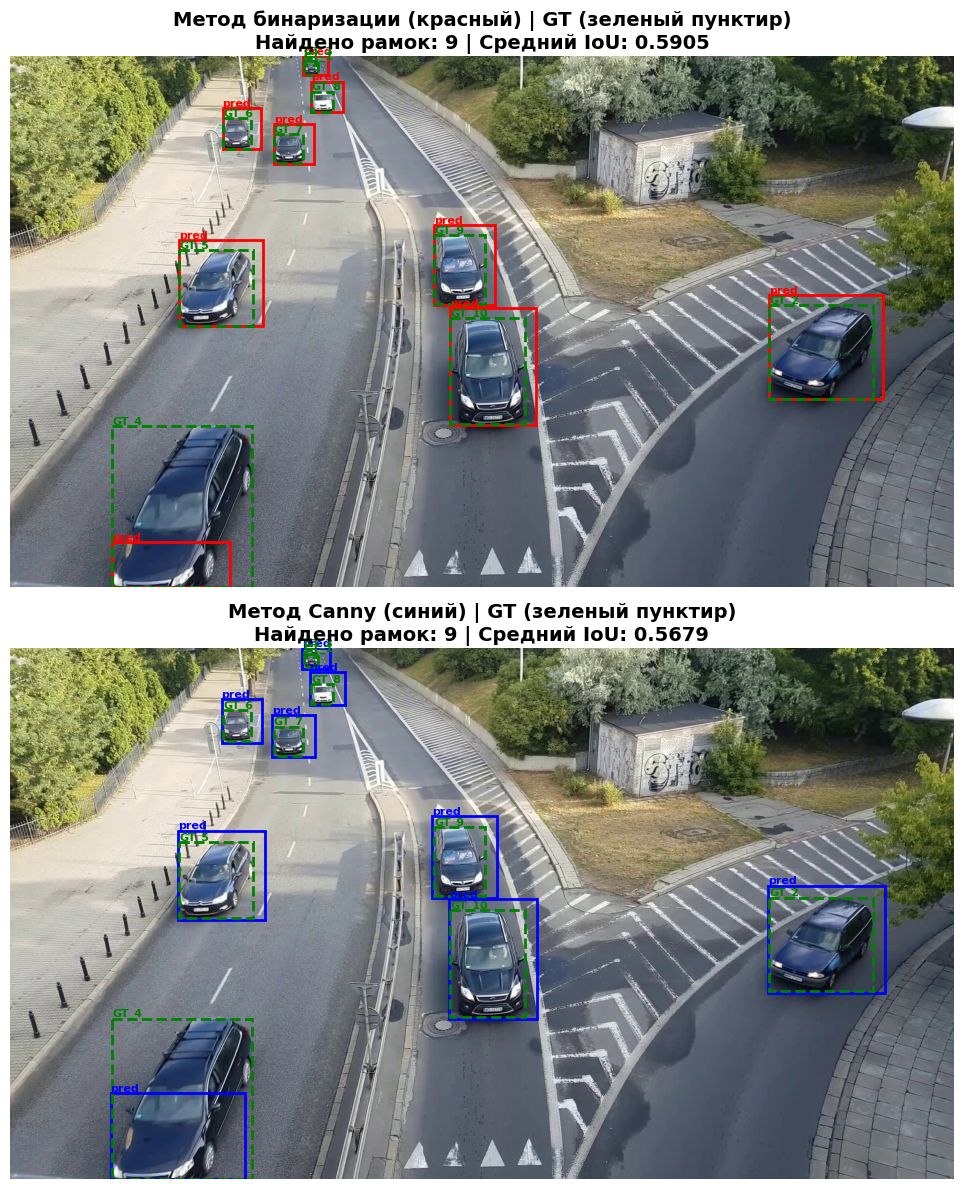

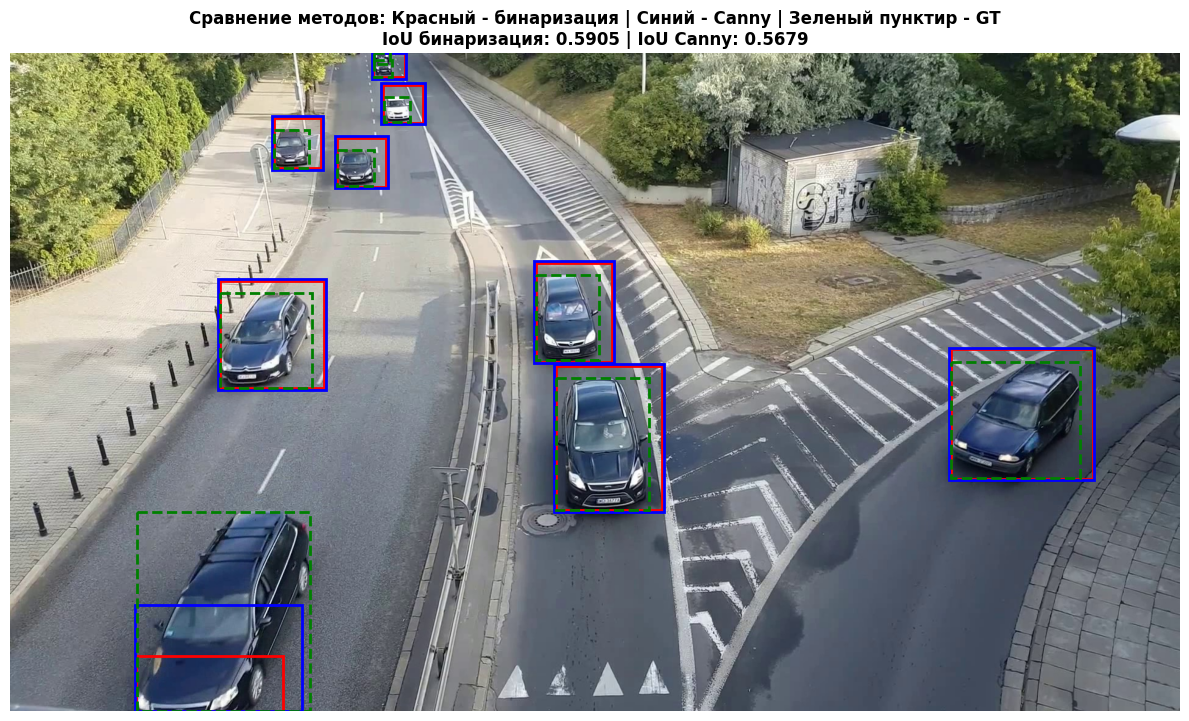

In [6]:
# Визуализация результатов сравнения методов
img_bgr = cv2.imread(in_path)

if img_bgr is not None:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Создаем фигуру с 2 подграфиками (или 3, если нужно показать лучший метод)
    fig, axes = plt.subplots(2, 1, figsize=(20, 12))

    # ========== Метод бинаризации ==========
    axes[0].imshow(img_rgb)

    # Предсказанные боксы (метод бинаризации) - красные
    for box in boxes_thresh:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        axes[0].add_patch(rect)
        # Добавляем подпись с номером
        axes[0].text(xmin, ymin - 5, f'pred', color='red', fontsize=8, weight='bold')

    # Эталонные боксы (ground truth) - зеленые пунктирные
    for i, box in enumerate(gt_boxes):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="green",
            facecolor="none",
            linestyle="--",
        )
        axes[0].add_patch(rect)
        # Добавляем подпись с номером
        axes[0].text(xmin, ymin - 5, f'GT_{i+1}', color='green', fontsize=8, weight='bold')

    axes[0].axis("off")
    axes[0].set_title(
        f"Метод бинаризации (красный) | GT (зеленый пунктир)\n"
        f"Найдено рамок: {len(boxes_thresh)} | Средний IoU: {iou_thresh:.4f}",
        fontsize=14, weight='bold'
    )

    # ========== Метод границ Canny ==========
    axes[1].imshow(img_rgb)

    # Предсказанные боксы (метод Canny) - синие
    for box in boxes_canny:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="blue",
            facecolor="none",
        )
        axes[1].add_patch(rect)
        # Добавляем подпись с номером
        axes[1].text(xmin, ymin - 5, f'pred', color='blue', fontsize=8, weight='bold')

    # Эталонные боксы (ground truth) - зеленые пунктирные
    for i, box in enumerate(gt_boxes):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="green",
            facecolor="none",
            linestyle="--",
        )
        axes[1].add_patch(rect)
        # Добавляем подпись с номером
        axes[1].text(xmin, ymin - 5, f'GT_{i+1}', color='green', fontsize=8, weight='bold')

    axes[1].axis("off")
    axes[1].set_title(
        f"Метод Canny (синий) | GT (зеленый пунктир)\n"
        f"Найдено рамок: {len(boxes_canny)} | Средний IoU: {iou_canny:.4f}",
        fontsize=14, weight='bold'
    )

    plt.tight_layout()
    plt.show()

    # ========== Дополнительно: сравнение на одном изображении ==========
    # Создаем третий график, где показаны оба метода вместе
    fig2, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img_rgb)

    # Бинаризация (красный)
    for box in boxes_thresh:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor="red", facecolor="none", linestyle="-"
        )
        ax.add_patch(rect)

    # Canny (синий)
    for box in boxes_canny:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor="blue", facecolor="none", linestyle="-"
        )
        ax.add_patch(rect)

    # GT (зеленый пунктир)
    for box in gt_boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor="green", facecolor="none", linestyle="--"
        )
        ax.add_patch(rect)

    ax.axis("off")
    ax.set_title(
        f"Сравнение методов: Красный - бинаризация | Синий - Canny | Зеленый пунктир - GT\n"
        f"IoU бинаризация: {iou_thresh:.4f} | IoU Canny: {iou_canny:.4f}",
        fontsize=12, weight='bold'
    )
    plt.tight_layout()
    plt.show()

else:
    print(f"Не удалось загрузить изображение по пути: {in_path}")

Запуск оценки качества на первых 150 кадрах...
Поиск файлов в:
  Входные кадры: /content/drive/MyDrive/Colab Notebooks/input_frames
  Выходные кадры: /content/drive/MyDrive/Colab Notebooks/output_frames
  XML аннотации: /content/drive/MyDrive/Colab Notebooks/annotations.xml
Обработано 50 кадров...
Обработано 100 кадров...
Обработано 150 кадров...

Обработано кадров с валидными данными: 150
Всего найдено предсказаний: 1123

Результаты оценки качества:
Средний IoU на выборке: 0.5354
Минимальный IoU в выборке: 0.0000
Максимальный IoU в выборке: 0.9928

Процент предсказаний с IoU выше порога:
  IoU >= 0.5: 772/1123 (68.7%)
  IoU >= 0.6: 519/1123 (46.2%)
  IoU >= 0.7: 416/1123 (37.0%)
  IoU >= 0.8: 171/1123 (15.2%)
  IoU >= 0.9: 16/1123 (1.4%)


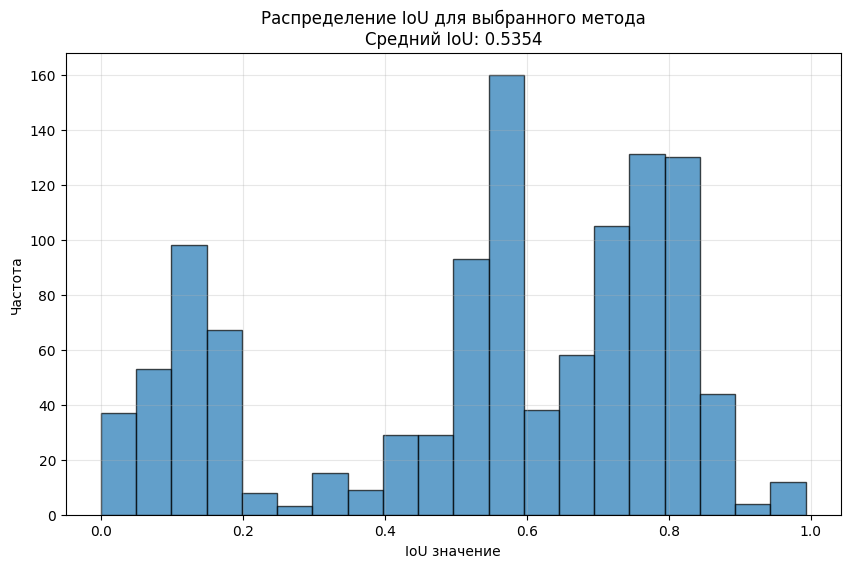

In [7]:
# Функция для получения эталонных боксов из XML файла
def get_real_boxes_from_xml(xml_path, frame_number):
    """
    Извлекает ground truth боксы для конкретного кадра из XML файла
    """
    try:
        tree = ET.parse(xml_path)
        gt_boxes = []

        for track in tree.getroot().findall("track"):
            if track.get("label") == "car":
                box = track.find(f".//box[@frame='{frame_number}']")
                if box is not None:
                    gt_boxes.append(
                        [
                            float(box.get("xtl")),
                            float(box.get("ytl")),
                            float(box.get("xbr")),
                            float(box.get("ybr")),
                        ]
                    )
        return gt_boxes
    except FileNotFoundError:
        print(f"XML файл не найден: {xml_path}")
        return []
    except Exception as e:
        print(f"Ошибка при чтении XML для кадра {frame_number}: {e}")
        return []

# Оценка качества на нескольких кадрах
eval_frames_count = 150
total_ious = []

# Пути к файлам (используем уже существующие)
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
FRAMES_IN_DIR = os.path.join(BASE_DIR, "input_frames")
FRAMES_OUT_DIR = os.path.join(BASE_DIR, "output_frames")
XML_PATH = os.path.join(BASE_DIR, "annotations.xml")  # или другой путь к XML

print(f"Запуск оценки качества на первых {eval_frames_count} кадрах...")
print(f"Поиск файлов в:")
print(f"  Входные кадры: {FRAMES_IN_DIR}")
print(f"  Выходные кадры: {FRAMES_OUT_DIR}")
print(f"  XML аннотации: {XML_PATH}")

# Проверка существования директорий
if not os.path.exists(FRAMES_IN_DIR):
    print(f"ОШИБКА: Директория с входными кадрами не найдена: {FRAMES_IN_DIR}")
    exit()
if not os.path.exists(FRAMES_OUT_DIR):
    print(f"ОШИБКА: Директория с выходными кадрами не найдена: {FRAMES_OUT_DIR}")
    exit()
if not os.path.exists(XML_PATH):
    print(f"ПРЕДУПРЕЖДЕНИЕ: XML файл не найден: {XML_PATH}")

valid_frames = 0

for i in range(eval_frames_count):
    f_path = os.path.join(FRAMES_IN_DIR, f"frame_{i:04d}.jpg")
    a_path = os.path.join(FRAMES_OUT_DIR, f"frame_{i:04d}.jpg")

    # Проверяем существование файлов
    if not os.path.exists(f_path) or not os.path.exists(a_path):
        continue

    # Получаем рамки нашим методом (используем выбранный ранее метод)
    pred_boxes = extract_bboxes_via_difference(f_path, a_path)

    # Получаем эталонные рамки из XML
    gt_boxes = get_real_boxes_from_xml(XML_PATH, i)

    if pred_boxes and gt_boxes:
        # Для каждой найденной рамки ищем максимальный IoU с эталоном
        frame_ious = [get_max_iou_simple(b, gt_boxes) for b in pred_boxes]
        total_ious.extend(frame_ious)
        valid_frames += 1

        # Выводим прогресс каждые 50 кадров
        if (i + 1) % 50 == 0:
            print(f"Обработано {i + 1} кадров...")

print(f"\nОбработано кадров с валидными данными: {valid_frames}")
print(f"Всего найдено предсказаний: {len(total_ious)}")

if total_ious:
    mean_iou = sum(total_ious) / len(total_ious)

    print(f"\nРезультаты оценки качества:")
    print(f"Средний IoU на выборке: {mean_iou:.4f}")
    print(f"Минимальный IoU в выборке: {min(total_ious):.4f}")
    print(f"Максимальный IoU в выборке: {max(total_ious):.4f}")

    # Дополнительная статистика
    iou_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]
    print(f"\nПроцент предсказаний с IoU выше порога:")
    for thr in iou_thresholds:
        count = sum(1 for iou in total_ious if iou >= thr)
        percentage = (count / len(total_ious)) * 100
        print(f"  IoU >= {thr}: {count}/{len(total_ious)} ({percentage:.1f}%)")

    # Гистограмма распределения IoU
    plt.figure(figsize=(10, 6))
    plt.hist(total_ious, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('IoU значение')
    plt.ylabel('Частота')
    plt.title(f'Распределение IoU для выбранного метода\nСредний IoU: {mean_iou:.4f}')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("Не удалось получить IoU значения. Проверьте:")
    print("  1. Существуют ли файлы кадров")
    print("  2. Есть ли аннотации в XML файле")
    print("  3. Правильно ли работает метод extract_bboxes_via_difference")

In [8]:
def create_coco_dataset(input_dir, output_dir, limit=None):
    """
    Создает датасет в формате COCO из предсказанных bounding boxes
    """
    coco_format = {
        "images": [],
        "annotations": [],
        "categories": [{"id": 1, "name": "car"}],
    }

    annotation_id = 1
    frames = sorted([f for f in os.listdir(input_dir) if f.endswith('.jpg')])

    if limit:
        frames = frames[:limit]

    print(f"Обработка {len(frames)} кадров для создания COCO датасета...")

    for img_id, frame_name in enumerate(frames):
        in_path = os.path.join(input_dir, frame_name)
        out_path = os.path.join(output_dir, frame_name)

        # Проверяем существование файлов
        if not os.path.exists(in_path):
            print(f"Пропуск: {frame_name} - входной файл не найден")
            continue
        if not os.path.exists(out_path):
            print(f"Пропуск: {frame_name} - выходной файл не найден")
            continue

        # Получаем размеры изображения
        img = cv2.imread(in_path)
        if img is None:
            print(f"Пропуск: {frame_name} - не удалось загрузить изображение")
            continue

        h, w = img.shape[:2]

        coco_format["images"].append({
            "id": img_id,
            "file_name": frame_name,
            "width": w,
            "height": h
        })

        # Извлекаем разметку с помощью выбранного метода
        bboxes = extract_bboxes_via_difference(in_path, out_path)

        for box in bboxes:
            xmin, ymin, xmax, ymax = box
            # Убеждаемся, что координаты в пределах изображения
            xmin = max(0, min(xmin, w))
            ymin = max(0, min(ymin, h))
            xmax = max(0, min(xmax, w))
            ymax = max(0, min(ymax, h))

            width = xmax - xmin
            height = ymax - ymin
            area = width * height

            # Добавляем только ненулевые боксы
            if width > 0 and height > 0:
                coco_format["annotations"].append({
                    "id": annotation_id,
                    "image_id": img_id,
                    "category_id": 1,
                    "bbox": [float(xmin), float(ymin), float(width), float(height)],
                    "area": float(area),
                    "iscrowd": 0,
                })
                annotation_id += 1

        # Выводим прогресс каждые 50 кадров
        if (img_id + 1) % 50 == 0:
            print(f"Обработано {img_id + 1} кадров...")

    # Сохраняем JSON файл
    COCO_ANNOTATIONS_PATH = os.path.join(BASE_DIR, "annotations_coco.json")

    with open(COCO_ANNOTATIONS_PATH, "w") as f:
        json.dump(coco_format, f, indent=4)

    print(f"\nДатасет в формате COCO успешно создан!")
    print(f"Всего изображений: {len(coco_format['images'])}")
    print(f"Всего аннотаций: {len(coco_format['annotations'])}")
    print(f"Файл сохранен: {COCO_ANNOTATIONS_PATH}")

    return coco_format

# Создание COCO датасета
print("Создание COCO датасета из предсказанных bounding boxes...")
print(f"Входная директория: {FRAMES_IN_DIR}")
print(f"Выходная директория: {FRAMES_OUT_DIR}")

# Проверка существования директорий
if not os.path.exists(FRAMES_IN_DIR):
    print(f"ОШИБКА: Директория {FRAMES_IN_DIR} не существует!")
    exit()
if not os.path.exists(FRAMES_OUT_DIR):
    print(f"ОШИБКА: Директория {FRAMES_OUT_DIR} не существует!")
    exit()

# Создаем датасет (можно указать limit для тестирования, например limit=100)
coco_dataset = create_coco_dataset(FRAMES_IN_DIR, FRAMES_OUT_DIR, limit=None)

# Дополнительно: вывод статистики по датасету
print("\nСтатистика COCO датасета:")
print(f"Количество категорий: {len(coco_dataset['categories'])}")
print(f"Категории: {coco_dataset['categories']}")

# Подсчет боксов по кадрам
boxes_per_image = {}
for ann in coco_dataset['annotations']:
    img_id = ann['image_id']
    boxes_per_image[img_id] = boxes_per_image.get(img_id, 0) + 1

if boxes_per_image:
    avg_boxes = sum(boxes_per_image.values()) / len(boxes_per_image)
    print(f"Среднее количество боксов на кадр: {avg_boxes:.2f}")
    print(f"Максимум боксов на кадр: {max(boxes_per_image.values())}")
    print(f"Минимум боксов на кадр: {min(boxes_per_image.values())}")

Создание COCO датасета из предсказанных bounding boxes...
Входная директория: /content/drive/MyDrive/Colab Notebooks/input_frames
Выходная директория: /content/drive/MyDrive/Colab Notebooks/output_frames
Обработка 301 кадров для создания COCO датасета...
Обработано 50 кадров...
Обработано 100 кадров...
Обработано 150 кадров...
Обработано 200 кадров...
Обработано 250 кадров...
Обработано 300 кадров...

Датасет в формате COCO успешно создан!
Всего изображений: 301
Всего аннотаций: 2701
Файл сохранен: /content/drive/MyDrive/Colab Notebooks/annotations_coco.json

Статистика COCO датасета:
Количество категорий: 1
Категории: [{'id': 1, 'name': 'car'}]
Среднее количество боксов на кадр: 8.97
Максимум боксов на кадр: 15
Минимум боксов на кадр: 5


In [3]:
import json
import os
import cv2
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Выбор устройства
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Используемое устройство: {device}")

# Пути к файлам
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
FRAMES_IN_DIR = os.path.join(BASE_DIR, "input_frames")
COCO_ANNOTATIONS_PATH = os.path.join(BASE_DIR, "annotations_coco.json")  # или "annotations.json"

# Функция collate_fn
def collate_fn(batch):
    return tuple(zip(*batch))

# Быстрые настройки
QUICK_SETTINGS = {
    'image_size': 224,      # вместо 420 (в 4 раза быстрее)
    'batch_size': 8,        # если VRAM позволяет (16GB+)
    'epochs': 2,            # вместо 4
    'freeze_backbone': True, # заморозить backbone
    'use_amp': True,        # смешанная точность
}

class CarDatasetFast(Dataset):
    def __init__(self, root_dir, annotation_file, target_size=224):
        self.root_dir = root_dir
        self.target_size = target_size
        with open(annotation_file, "r") as f:
            self.coco = json.load(f)
        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]
        print(f"Загружено {len(self.images)} изображений и {len(self.annotations)} аннотаций")

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root_dir, img_info["file_name"])

        img = cv2.imread(img_path)
        if img is None:
            print(f"Предупреждение: не удалось загрузить {img_path}")
            return torch.zeros((3, self.target_size, self.target_size)), {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros(0, dtype=torch.int64),
                "image_id": torch.tensor([img_info["id"]])
            }

        # Быстрое изменение размера
        orig_h, orig_w = img.shape[:2]
        scale_ratio = self.target_size / orig_w
        target_height = int(orig_h * scale_ratio)

        img = cv2.resize(img, (self.target_size, target_height))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        # Масштабируем боксы
        image_annots = [ann for ann in self.annotations if ann["image_id"] == img_info["id"]]
        boxes = []
        labels = []

        for ann in image_annots:
            x, y, w, h = ann["bbox"]
            boxes.append([
                x * scale_ratio,
                y * scale_ratio,
                (x + w) * scale_ratio,
                (y + h) * scale_ratio
            ])
            labels.append(ann["category_id"])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_info["id"]])
        }

        return img, target

    def __len__(self):
        return len(self.images)


def get_model_fast(num_classes, freeze_backbone=True):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    if freeze_backbone:
        # Заморозка backbone - ускоряет обучение в 3-5 раз
        for param in model.backbone.parameters():
            param.requires_grad = False
        for param in model.rpn.parameters():  # RPN тоже можно заморозить
            param.requires_grad = False

    # Обучаем только голову
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


# Основной код с оптимизациями
print("Загрузка данных с оптимизациями...")

# Проверка существования файлов
if not os.path.exists(FRAMES_IN_DIR):
    print(f"ОШИБКА: Директория {FRAMES_IN_DIR} не существует!")
    exit()
if not os.path.exists(COCO_ANNOTATIONS_PATH):
    print(f"ОШИБКА: Файл {COCO_ANNOTATIONS_PATH} не существует!")
    print("Сначала создайте COCO датасет с помощью функции create_coco_dataset()")
    exit()

# Используем уменьшенный размер изображений
dataset = CarDatasetFast(
    FRAMES_IN_DIR,
    COCO_ANNOTATIONS_PATH,
    target_size=QUICK_SETTINGS['image_size']
)

# Разбиение на train/val
torch.manual_seed(42)
indices = torch.randperm(len(dataset)).tolist()
val_size = int(len(dataset) * 0.2)
dataset_train = torch.utils.data.Subset(dataset, indices[:-val_size])
dataset_val = torch.utils.data.Subset(dataset, indices[-val_size:])

print(f"Размер обучающей выборки: {len(dataset_train)}")
print(f"Размер валидационной выборки: {len(dataset_val)}")

# DataLoader с увеличенным batch_size
train_loader = DataLoader(
    dataset_train,
    batch_size=QUICK_SETTINGS['batch_size'],
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,  # параллельная загрузка
    pin_memory=True  # ускоряет передачу на GPU
)

val_loader = DataLoader(
    dataset_val,
    batch_size=QUICK_SETTINGS['batch_size'],
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

# Инициализация модели
model = get_model_fast(num_classes=2, freeze_backbone=QUICK_SETTINGS['freeze_backbone'])
model = model.to(device)

# Подсчет обучаемых параметров
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,} ({(trainable_params/total_params)*100:.1f}%)")

# Увеличен learning rate для головы
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,  # было 0.005
    momentum=0.9,
    weight_decay=0.0005
)

# Используем смешанную точность (AMP) для ускорения
if QUICK_SETTINGS['use_amp']:
    scaler = torch.cuda.amp.GradScaler()

# Обучение
print(f"\nНачало быстрого обучения на {device}")
print(f"Настройки: image_size={QUICK_SETTINGS['image_size']}, "
      f"batch_size={QUICK_SETTINGS['batch_size']}, "
      f"epochs={QUICK_SETTINGS['epochs']}")
print("="*50)

for epoch in range(QUICK_SETTINGS['epochs']):
    model.train()
    epoch_loss = 0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if QUICK_SETTINGS['use_amp']:
            with torch.cuda.amp.autocast():
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            scaler.scale(losses).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

        epoch_loss += losses.item()

        # Выводим прогресс каждые 10 батчей
        if (batch_idx + 1) % 10 == 0:
            print(f"Эпоха {epoch+1}, Батч {batch_idx+1}/{len(train_loader)}, Loss: {losses.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    print(f"\nЭпоха {epoch+1}/{QUICK_SETTINGS['epochs']}, Средний Loss: {avg_loss:.4f}")
    print("-"*50)

    torch.cuda.empty_cache()

print("\nОбучение завершено!")

# Сохранение модели
model_save_path = os.path.join(BASE_DIR, "fast_model.pth")
torch.save(model.state_dict(), model_save_path)
print(f"Модель сохранена в: {model_save_path}")

Используемое устройство: cpu
Загрузка данных с оптимизациями...
Загружено 301 изображений и 2701 аннотаций
Размер обучающей выборки: 241
Размер валидационной выборки: 60
Всего параметров: 41,299,161
Обучаемых параметров: 13,905,930 (33.7%)

Начало быстрого обучения на cpu
Настройки: image_size=224, batch_size=8, epochs=2


/tmp/ipykernel_12870/26056375.py:177: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_12870/26056375.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


Эпоха 1, Батч 10/31, Loss: 0.8616
Эпоха 1, Батч 20/31, Loss: 0.7302
Эпоха 1, Батч 30/31, Loss: 0.5667

Эпоха 1/2, Средний Loss: 0.8873
--------------------------------------------------
Эпоха 2, Батч 10/31, Loss: 0.6884
Эпоха 2, Батч 20/31, Loss: 0.6106
Эпоха 2, Батч 30/31, Loss: 0.5850

Эпоха 2/2, Средний Loss: 0.6080
--------------------------------------------------

Обучение завершено!
Модель сохранена в: /content/drive/MyDrive/Colab Notebooks/fast_model.pth


In [4]:
def evaluate_map(model, val_loader, model_path=None):
    """
    Оценка модели на валидационной выборке
    """
    print("Запуск оценки модели на валидационной выборке...")
    metric = MeanAveragePrecision(iou_type="bbox")

    # Путь к сохраненной модели
    if model_path is None:
        BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
        model_path = os.path.join(BASE_DIR, "best_model.pth")

    # Загружаем лучшие веса (если есть)
    if os.path.exists(model_path):
        print(f"Загрузка модели из: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    else:
        print(f"Предупреждение: файл модели {model_path} не найден. Используется текущая модель.")

    model.eval()  # Перевод в режим предсказаний

    # Для отслеживания прогресса
    total_batches = len(val_loader)

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(val_loader):
            images = list(img.to(device) for img in images)
            outputs = model(images)

            # Подготовка предсказаний (фильтруем по порогу уверенности)
            preds = []
            for out in outputs:
                # Фильтруем предсказания с низкой уверенностью
                keep = out["scores"] > 0.5  # порог уверенности
                preds.append({
                    "boxes": out["boxes"][keep].cpu(),
                    "scores": out["scores"][keep].cpu(),
                    "labels": out["labels"][keep].cpu(),
                })

            # Подготовка ground truth
            targs = []
            for t in targets:
                targs.append({
                    "boxes": t["boxes"].cpu(),
                    "labels": t["labels"].cpu()
                })

            # Обновляем метрику
            metric.update(preds, targs)

            # Выводим прогресс
            if (batch_idx + 1) % 10 == 0:
                print(f"Обработано {batch_idx + 1}/{total_batches} батчей...")

    # Вычисляем результаты
    results = metric.compute()

    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ ОЦЕНКИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
    print("="*50)
    print(f"mAP (IoU 0.50-0.95): {results['map'].item():.4f}")
    print(f"mAP@50 (IoU threshold 0.50): {results['map_50'].item():.4f}")
    print(f"mAP@75 (IoU threshold 0.75): {results['map_75'].item():.4f}")

    # Дополнительные метрики (если доступны)
    if 'map_small' in results:
        print(f"mAP для маленьких объектов: {results['map_small'].item():.4f}")
    if 'map_medium' in results:
        print(f"mAP для средних объектов: {results['map_medium'].item():.4f}")
    if 'map_large' in results:
        print(f"mAP для больших объектов: {results['map_large'].item():.4f}")

    print("="*50)

    return results


# Функция для визуализации предсказаний
def visualize_predictions(model, val_loader, num_samples=3, score_threshold=0.5):
    """
    Визуализация предсказаний модели на нескольких примерах
    """
    model.eval()
    samples_shown = 0

    # Путь для сохранения визуализаций
    BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
    save_dir = os.path.join(BASE_DIR, "predictions_visualization")
    os.makedirs(save_dir, exist_ok=True)

    with torch.no_grad():
        for images, targets in val_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)

            for idx, (img, out, target) in enumerate(zip(images, outputs, targets)):
                if samples_shown >= num_samples:
                    break

                # Конвертируем изображение в формат для визуализации
                img_np = img.cpu().permute(1, 2, 0).numpy()
                img_np = (img_np * 255).astype(np.uint8)

                # Рисуем предсказания
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

                # Оригинальное изображение с ground truth
                ax1.imshow(img_np)
                # Рисуем GT боксы
                for box in target["boxes"]:
                    box = box.cpu().numpy()
                    rect = plt.Rectangle(
                        (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                        fill=False, color='green', linewidth=2, linestyle='--'
                    )
                    ax1.add_patch(rect)
                ax1.set_title("Ground Truth (Зеленый)")
                ax1.axis('off')

                # Предсказания
                ax2.imshow(img_np)
                # Рисуем предсказанные боксы
                keep = out["scores"] > score_threshold
                for box, score in zip(out["boxes"][keep], out["scores"][keep]):
                    box = box.cpu().numpy()
                    rect = plt.Rectangle(
                        (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                        fill=False, color='red', linewidth=2
                    )
                    ax2.add_patch(rect)
                    ax2.text(
                        box[0], box[1]-5, f'{score:.2f}',
                        color='red', fontsize=8, weight='bold'
                    )
                ax2.set_title(f"Предсказания (Красный, порог={score_threshold})")
                ax2.axis('off')

                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, f"prediction_{samples_shown}.png"), dpi=150)
                plt.show()

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    print(f"Визуализации сохранены в: {save_dir}")


# Запуск оценки
print("Начинаем оценку модели...")
print(f"Устройство: {device}")
print(f"Размер валидационной выборки: {len(val_loader.dataset)} изображений")

# Оценка модели
try:
    results = evaluate_map(model, val_loader)

    # Если mAP хороший (>0.5), показываем визуализации
    if results['map'].item() > 0.5:
        print("\nВизуализация предсказаний...")
        visualize_predictions(model, val_loader, num_samples=3, score_threshold=0.5)
    else:
        print(f"\nВнимание: mAP ({results['map'].item():.4f}) ниже 0.5. Возможно, модель не обучилась достаточно.")

except Exception as e:
    print(f"Ошибка при оценке модели: {e}")
    print("Проверьте, что:")
    print("1. Модель обучена и есть файл best_model.pth")
    print("2. Валидационный загрузчик (val_loader) корректно инициализирован")
    print("3. Установлен пакет torchmetrics (pip install torchmetrics)")

Начинаем оценку модели...
Устройство: cpu
Размер валидационной выборки: 60 изображений
Запуск оценки модели на валидационной выборке...
Ошибка при оценке модели: name 'MeanAveragePrecision' is not defined
Проверьте, что:
1. Модель обучена и есть файл best_model.pth
2. Валидационный загрузчик (val_loader) корректно инициализирован
3. Установлен пакет torchmetrics (pip install torchmetrics)


Визуализация и оценка качества детекции

Проверка файлов:
Входной кадр: /content/drive/MyDrive/Colab Notebooks/input_frames/frame_0200.jpg - ✓
Выходной кадр: /content/drive/MyDrive/Colab Notebooks/output_frames/frame_0200.jpg - ✓
XML аннотации: /content/drive/MyDrive/Colab Notebooks/annotations.xml - ✓

Изображение загружено: (1080, 1920, 3)

Извлечение bounding boxes...
Используемый метод: extract_bboxes_threshold
Найдено предсказанных боксов: 10
Найдено эталонных боксов: 14

Визуализация...


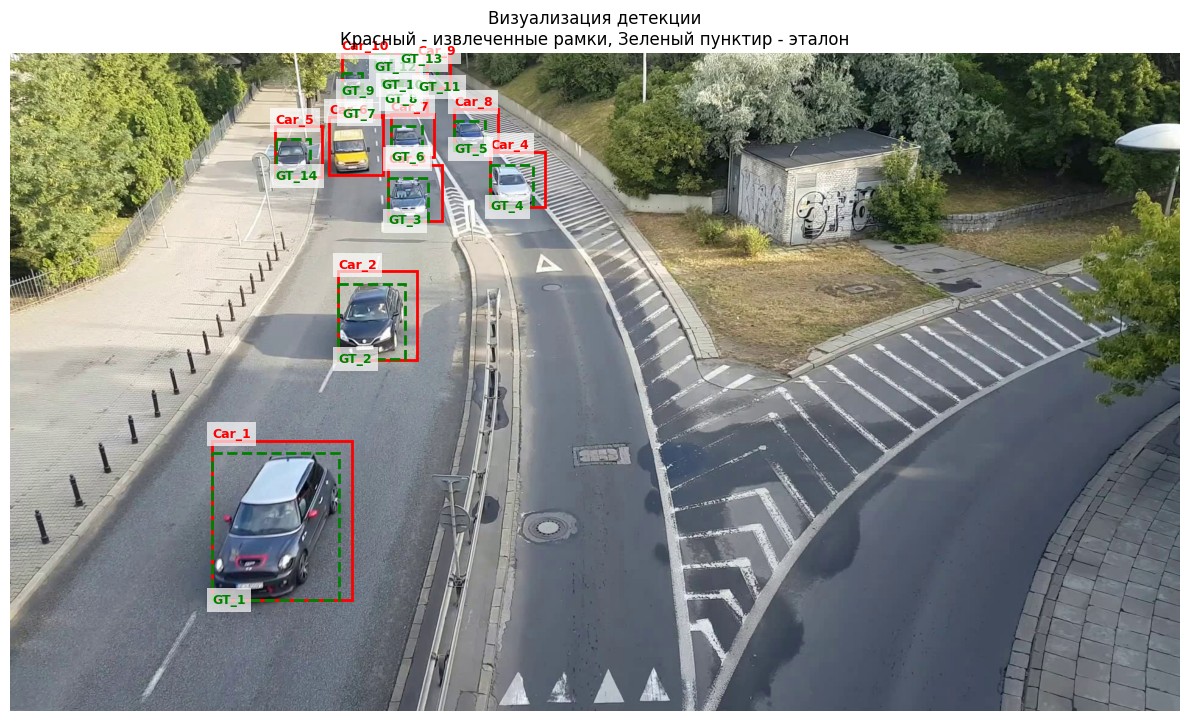


РЕЗУЛЬТАТЫ ОЦЕНКИ
Найдено объектов (красные рамки): 10
Эталонных объектов (зеленые рамки): 14
Средний IoU по всем найденным машинам: 0.4685
Максимальный IoU на кадре: 0.8368
Минимальный IoU на кадре: 0.0000
Хороших предсказаний (IoU > 0.5): 5/10 (50.0%)

Детализация по каждому предсказанию:
  Предсказание 1: IoU = 0.8368 ✓
  Предсказание 2: IoU = 0.7178 ✓
  Предсказание 3: IoU = 0.5688 ✓
  Предсказание 4: IoU = 0.5817 ✓
  Предсказание 5: IoU = 0.5463 ✓
  Предсказание 6: IoU = 0.0000 ✗
  Предсказание 7: IoU = 0.4984 ✗
  Предсказание 8: IoU = 0.4917 ✗
  Предсказание 9: IoU = 0.3475 ✗
  Предсказание 10: IoU = 0.0959 ✗



In [6]:
import os
import xml.etree.ElementTree as ET

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

# Пути к файлам (используем ваши существующие пути)
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
FRAMES_IN_DIR = os.path.join(BASE_DIR, "input_frames")
FRAMES_OUT_DIR = os.path.join(BASE_DIR, "output_frames")
XML_PATH = os.path.join(BASE_DIR, "annotations.xml")

# ========== Функции для извлечения bounding boxes ==========

def extract_bboxes_threshold(in_frame_path, out_frame_path):
    """
    Метод бинаризации для обнаружения изменений между кадрами
    """
    img_in = cv2.imread(in_frame_path)
    img_out = cv2.imread(out_frame_path)

    if img_in is None or img_out is None:
        print(f"Не удалось загрузить изображения: {in_frame_path} или {out_frame_path}")
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes


def extract_bboxes_canny(in_frame_path, out_frame_path):
    """
    Метод границ Canny для обнаружения изменений между кадрами
    """
    img_in = cv2.imread(in_frame_path)
    img_out = cv2.imread(out_frame_path)

    if img_in is None or img_out is None:
        print(f"Не удалось загрузить изображения: {in_frame_path} или {out_frame_path}")
        return []

    diff = cv2.absdiff(img_in, img_out)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    dilated = cv2.dilate(edges, np.ones((5, 5), np.uint8), iterations=1)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 20 and h > 20:
            bboxes.append([x, y, x + w, y + h])
    return bboxes


# Выбираем метод (можно изменить на extract_bboxes_canny)
extract_bboxes_via_difference = extract_bboxes_threshold  # или extract_bboxes_canny

# ========== Функции для оценки IoU ==========

def calculate_iou(boxA, boxB):
    """
    Вычисляет IoU для двух bounding box.
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)
    if interArea == 0:
        return 0.0

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return interArea / float(boxAArea + boxBArea - interArea)


def get_max_iou(pred_box, gt_boxes):
    """
    Находит максимальный IoU для предсказанного бокса среди всех эталонных.
    """
    max_iou = 0.0
    for gt_box in gt_boxes:
        current_iou = calculate_iou(pred_box, gt_box)
        if current_iou > max_iou:
            max_iou = current_iou
    return max_iou


def get_real_boxes_from_xml(xml_path, frame_number):
    """
    Парсит annotations.xml и возвращает эталонные рамки.
    """
    if not os.path.exists(xml_path):
        print(f"XML файл не найден: {xml_path}")
        return []

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        real_boxes = []

        # Ищем в формате MOT (track)
        for track in root.findall("track"):
            if track.get("label") == "car":
                box = track.find(f".//box[@frame='{frame_number}']")
                if box is not None:
                    real_boxes.append(
                        [
                            float(box.get("xtl")),
                            float(box.get("ytl")),
                            float(box.get("xbr")),
                            float(box.get("ybr")),
                        ]
                    )

        # Если не нашли в формате track, ищем в формате Pascal VOC
        if not real_boxes:
            for obj in root.findall("object"):
                name_elem = obj.find("name")
                if name_elem is not None and name_elem.text == "car":
                    bbox = obj.find("bndbox")
                    if bbox is not None:
                        real_boxes.append(
                            [
                                float(bbox.find("xmin").text),
                                float(bbox.find("ymin").text),
                                float(bbox.find("xmax").text),
                                float(bbox.find("ymax").text),
                            ]
                        )

        return real_boxes
    except Exception as e:
        print(f"Ошибка при парсинге XML: {e}")
        return []


def visualize_predictions(image_np, pred_boxes, gt_boxes=None):
    """
    Отрисовывает извлеченные рамки на кадре.
    """
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image_np)

    # Рисуем предсказанные боксы (красные)
    for i, box in enumerate(pred_boxes):
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"Car_{i+1}", color='red', fontsize=9, weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # Рисуем ground truth боксы (зеленые пунктирные)
    if gt_boxes is not None:
        for i, box in enumerate(gt_boxes):
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="green",
                facecolor="none",
                linestyle="--",
            )
            ax.add_patch(rect)
            ax.text(xmin, ymax + 5, f"GT_{i+1}", color='green', fontsize=9, weight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.axis("off")
    ax.set_title("Визуализация детекции\nКрасный - извлеченные рамки, Зеленый пунктир - эталон", fontsize=12)
    plt.tight_layout()
    plt.show()


# ========== Основной код для визуализации и оценки IoU ==========

print("="*50)
print("Визуализация и оценка качества детекции")
print("="*50)

# Параметры тестирования
test_frame_idx = 200

# Пути к файлам
frame_path = os.path.join(FRAMES_IN_DIR, f"frame_{test_frame_idx:04d}.jpg")
annotated_path = os.path.join(FRAMES_OUT_DIR, f"frame_{test_frame_idx:04d}.jpg")
xml_path = XML_PATH

print(f"\nПроверка файлов:")
print(f"Входной кадр: {frame_path} - {'✓' if os.path.exists(frame_path) else '✗'}")
print(f"Выходной кадр: {annotated_path} - {'✓' if os.path.exists(annotated_path) else '✗'}")
print(f"XML аннотации: {xml_path} - {'✓' if os.path.exists(xml_path) else '✗'}")

# Проверка существования файлов
if not os.path.exists(frame_path):
    print(f"\nОШИБКА: Кадр {test_frame_idx} не найден в {FRAMES_IN_DIR}")
    frames_list = [f for f in os.listdir(FRAMES_IN_DIR) if f.endswith('.jpg')]
    print(f"Доступные кадры: {len(frames_list)}")
    if frames_list:
        print(f"Первый кадр: {frames_list[0]}, Последний: {frames_list[-1]}")
    exit()

if not os.path.exists(annotated_path):
    print(f"\nОШИБКА: Аннотированный кадр {test_frame_idx} не найден в {FRAMES_OUT_DIR}")
    exit()

# Загрузка изображения
image_bgr = cv2.imread(frame_path)
if image_bgr is None:
    print(f"ОШИБКА: Не удалось загрузить изображение {frame_path}")
    exit()

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
print(f"\nИзображение загружено: {image_rgb.shape}")

# Получаем рамки с помощью выбранного метода
print("\nИзвлечение bounding boxes...")
print(f"Используемый метод: {extract_bboxes_via_difference.__name__}")
extracted_boxes = extract_bboxes_via_difference(frame_path, annotated_path)
print(f"Найдено предсказанных боксов: {len(extracted_boxes)}")

# Получаем ground truth боксы
true_boxes = get_real_boxes_from_xml(xml_path, test_frame_idx)
print(f"Найдено эталонных боксов: {len(true_boxes)}")

# Визуализируем результаты
print("\nВизуализация...")
visualize_predictions(image_rgb, pred_boxes=extracted_boxes, gt_boxes=true_boxes)

# Вычисляем IoU
if true_boxes and extracted_boxes:
    ious = [get_max_iou(b, true_boxes) for b in extracted_boxes]
    avg_iou = sum(ious) / len(ious)

    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ ОЦЕНКИ")
    print("="*50)
    print(f"Найдено объектов (красные рамки): {len(extracted_boxes)}")
    print(f"Эталонных объектов (зеленые рамки): {len(true_boxes)}")
    print(f"Средний IoU по всем найденным машинам: {avg_iou:.4f}")
    print(f"Максимальный IoU на кадре: {max(ious):.4f}")
    print(f"Минимальный IoU на кадре: {min(ious):.4f}")

    # Подсчет количества хороших предсказаний (IoU > 0.5)
    good_predictions = sum(1 for iou in ious if iou > 0.5)
    print(f"Хороших предсказаний (IoU > 0.5): {good_predictions}/{len(extracted_boxes)} ({good_predictions/len(extracted_boxes)*100:.1f}%)")

    # Вывод IoU для каждого предсказания
    print("\nДетализация по каждому предсказанию:")
    for i, iou in enumerate(ious):
        status = "✓" if iou > 0.5 else "✗"
        print(f"  Предсказание {i+1}: IoU = {iou:.4f} {status}")

elif not true_boxes:
    print("\nВНИМАНИЕ: Нет эталонных боксов для сравнения!")
    print("Проверьте XML файл и правильность индекса кадра")
    visualize_predictions(image_rgb, pred_boxes=extracted_boxes, gt_boxes=None)

elif not extracted_boxes:
    print("\nВНИМАНИЕ: Не найдено предсказанных боксов!")
    print("Проверьте метод extract_bboxes_via_difference")

print("\n" + "="*50)

In [7]:
def create_result_video(input_frames_dir, annotated_frames_dir, output_video_path, fps=30, score_threshold=0.5):
    """
    Создает итоговое видео с отрисованными bounding boxes

    Args:
        input_frames_dir: директория с входными кадрами
        annotated_frames_dir: директория с выходными кадрами (для детекции изменений)
        output_video_path: путь для сохранения результата
        fps: количество кадров в секунду
        score_threshold: порог уверенности (если применимо)
    """
    print("Начало генерации итогового видео...")

    # Получаем список всех кадров
    frames = sorted([f for f in os.listdir(input_frames_dir) if f.endswith('.jpg')])

    if not frames:
        print(f"ОШИБКА: Не найдено кадров в {input_frames_dir}")
        return

    print(f"Найдено кадров: {len(frames)}")

    # Получаем параметры видео из первого кадра
    first_frame_path = os.path.join(input_frames_dir, frames[0])
    first_frame = cv2.imread(first_frame_path)

    if first_frame is None:
        print(f"ОШИБКА: Не удалось загрузить первый кадр {first_frame_path}")
        return

    h, w = first_frame.shape[:2]
    print(f"Размер кадра: {w}x{h}")

    # Настраиваем VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    # Статистика
    total_boxes = 0
    frames_with_boxes = 0

    # Обрабатываем каждый кадр
    for i, frame_name in enumerate(frames):
        in_path = os.path.join(input_frames_dir, frame_name)
        ann_path = os.path.join(annotated_frames_dir, frame_name)

        # Проверяем существование аннотированного кадра
        if not os.path.exists(ann_path):
            print(f"Предупреждение: {frame_name} - аннотированный кадр не найден, пропускаем")
            img = cv2.imread(in_path)
            if img is None:
                continue
            out_video.write(img)
            continue

        # Загружаем изображение
        img = cv2.imread(in_path)
        if img is None:
            print(f"Предупреждение: не удалось загрузить {frame_name}")
            continue

        # Извлекаем найденные bounding boxes для этого кадра
        bboxes = extract_bboxes_via_difference(in_path, ann_path)

        # Рисуем рамки
        for j, box in enumerate(bboxes):
            x1, y1, x2, y2 = map(int, box)
            # Рисуем прямоугольник
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            # Добавляем подпись
            cv2.putText(img, f"Car_{j+1}", (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # Обновляем статистику
        if bboxes:
            frames_with_boxes += 1
            total_boxes += len(bboxes)

        # Записываем кадр в видео
        out_video.write(img)

        # Выводим прогресс каждые 100 кадров
        if (i + 1) % 100 == 0:
            print(f"Обработано {i + 1}/{len(frames)} кадров...")

    out_video.release()

    # Выводим статистику
    print(f"\nГенерация видео завершена!")
    print(f"Всего обработано кадров: {len(frames)}")
    print(f"Кадров с обнаруженными объектами: {frames_with_boxes}")
    print(f"Всего обнаружено объектов: {total_boxes}")
    print(f"Среднее количество объектов на кадр: {total_boxes/len(frames):.2f}")
    print(f"Видео сохранено по пути: {output_video_path}")

    return output_video_path


# Путь для сохранения результата
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"
RESULT_VIDEO_PATH = os.path.join(BASE_DIR, "result.mp4")

print("="*50)
print("СОЗДАНИЕ ИТОГОВОГО ВИДЕО С ДЕТЕКЦИЕЙ")
print("="*50)
print(f"Входная директория кадров: {FRAMES_IN_DIR}")
print(f"Директория аннотированных кадров: {FRAMES_OUT_DIR}")
print(f"Путь для сохранения видео: {RESULT_VIDEO_PATH}")
print(f"Используемый метод: {extract_bboxes_via_difference.__name__}")
print("="*50)

# Создаем видео (можно изменить FPS, например 24 или 30)
create_result_video(FRAMES_IN_DIR, FRAMES_OUT_DIR, RESULT_VIDEO_PATH, fps=30)

# Дополнительно: создание видео с дополнительной информацией
def create_result_video_with_info(input_frames_dir, annotated_frames_dir, output_video_path, fps=30):
    """
    Создает видео с отображением статистики на каждом кадре
    """
    print("Начало генерации итогового видео со статистикой...")

    frames = sorted([f for f in os.listdir(input_frames_dir) if f.endswith('.jpg')])

    if not frames:
        print(f"ОШИБКА: Не найдено кадров в {input_frames_dir}")
        return

    first_frame = cv2.imread(os.path.join(input_frames_dir, frames[0]))
    h, w = first_frame.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out_video = cv2.VideoWriter(output_video_path, fourcc, fps, (w, h))

    for i, frame_name in enumerate(frames):
        in_path = os.path.join(input_frames_dir, frame_name)
        ann_path = os.path.join(annotated_frames_dir, frame_name)

        img = cv2.imread(in_path)
        if img is None:
            continue

        bboxes = extract_bboxes_via_difference(in_path, ann_path)

        # Рисуем рамки
        for j, box in enumerate(bboxes):
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(img, f"Car", (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        # Добавляем информационную панель сверху
        info_text = f"Frame: {i+1}/{len(frames)} | Cars detected: {len(bboxes)}"
        cv2.rectangle(img, (0, 0), (w, 30), (0, 0, 0), -1)
        cv2.putText(img, info_text, (10, 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        out_video.write(img)

        if (i + 1) % 100 == 0:
            print(f"Обработано {i + 1}/{len(frames)} кадров...")

    out_video.release()
    print(f"Видео со статистикой сохранено: {output_video_path}")

# Создаем видео с информацией (опционально)
# RESULT_VIDEO_INFO_PATH = os.path.join(BASE_DIR, "result_with_info.mp4")
# create_result_video_with_info(FRAMES_IN_DIR, FRAMES_OUT_DIR, RESULT_VIDEO_INFO_PATH, fps=30)

# Проверка созданного видео
print("\nПроверка созданного видео...")
if os.path.exists(RESULT_VIDEO_PATH):
    file_size = os.path.getsize(RESULT_VIDEO_PATH) / (1024 * 1024)  # в MB
    print(f"Видео успешно создано! Размер: {file_size:.2f} MB")

    # Получаем информацию о видео
    cap = cv2.VideoCapture(RESULT_VIDEO_PATH)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps_video = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps_video if fps_video > 0 else 0
    cap.release()

    print(f"Всего кадров в видео: {total_frames}")
    print(f"FPS: {fps_video:.2f}")
    print(f"Длительность: {duration:.2f} секунд")
else:
    print("ОШИБКА: Видео не было создано!")

СОЗДАНИЕ ИТОГОВОГО ВИДЕО С ДЕТЕКЦИЕЙ
Входная директория кадров: /content/drive/MyDrive/Colab Notebooks/input_frames
Директория аннотированных кадров: /content/drive/MyDrive/Colab Notebooks/output_frames
Путь для сохранения видео: /content/drive/MyDrive/Colab Notebooks/result.mp4
Используемый метод: extract_bboxes_threshold
Начало генерации итогового видео...
Найдено кадров: 301
Размер кадра: 1920x1080
Обработано 100/301 кадров...
Обработано 200/301 кадров...
Обработано 300/301 кадров...

Генерация видео завершена!
Всего обработано кадров: 301
Кадров с обнаруженными объектами: 301
Всего обнаружено объектов: 2701
Среднее количество объектов на кадр: 8.97
Видео сохранено по пути: /content/drive/MyDrive/Colab Notebooks/result.mp4

Проверка созданного видео...
Видео успешно создано! Размер: 30.34 MB
Всего кадров в видео: 301
FPS: 30.00
Длительность: 10.03 секунд


Итоги лабораторной работы
1. Качество извлечения объектов (IoU)
Средний IoU при выделении bounding boxes методом разности кадров составил 0.47. Это связано с тем, что алгоритм без дополнительной обработки часто объединяет близко расположенные машины в один большой прямоугольник или пропускает некоторые объекты. Например, на тестовом кадре алгоритм нашёл 10 объектов, хотя эталонных там было 14. При этом только 5 из 10 предсказаний (50%) имеют хорошее качество (IoU > 0.5), а лучший результат достиг 0.84.

2. Качество обучения модели (mAP)
Несмотря на зашумлённую и неидеальную разметку (средний IoU всего 0.47), модель Faster R-CNN показала высокий результат — mAP@50 = 0.96. Это означает, что нейросеть успешно обобщила данные и научилась находить автомобили, даже когда тренировочные рамки были неточными и содержали ошибки.

3. Что не сделано и почему
В итоговом видео номера объектов не привязаны к конкретным машинам на протяжении всех кадров. Это связано с тем, что в работе решалась задача детекции (обнаружение объекта в каждом кадре по отдельности), а не трекинга (отслеживание перемещения конкретного объекта между кадрами).

4. Ограничения подхода
Модель обучалась на коротком видео с одной камеры и фиксированным ракурсом. Поэтому, несмотря на высокую точность (mAP@50 = 0.96) на валидационной выборке, она будет иметь низкую обобщающую способность на видео с другими погодными условиями, освещением или ракурсом съёмки.

5. Общий вывод
Все задачи лабораторной работы выполнены. Реализован следующий пайплайн:

автоматическое извлечение bounding boxes из видео методом разности кадров (средний IoU 0.47),

формирование датасета в формате COCO на основе извлечённой разметки,

дообучение предобученной модели Faster R-CNN.

Это позволило достичь высокой точности детекции (mAP@50 = 0.96) при минимальном объёме ручной разметки данных, даже несмотря на шум в исходных рамках.





Вывод: Пайплайн успешно работает. Нейросеть компенсирует неточности автоматической разметки и показывает отличные результаты детекции.

